In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [3]:
# 1. Setup Data Length (1 year of hourly data = 8760 rows)
num_hours = 8760
start_date = datetime(2025, 1, 1, 0, 0, 0)
timestamps = [start_date + timedelta(hours=i) for i in range(num_hours)]

In [4]:
# 2. Initialize Data Dictionary
data = {
    'Timestamp': timestamps,
    'Hour_of_Day': [t.hour for t in timestamps],
    'Day_of_Week': [t.weekday() for t in timestamps],
    'Month': [t.month for t in timestamps],
}

df = pd.DataFrame(data)

In [5]:
# 3. Simulate Weather (Temperature and Rain)
# Temp is higher in summer (mid-year) and higher in the afternoon
yearly_temp_cycle = -10 * np.cos(2 * np.pi * df['Month'] / 12) + 20 
daily_temp_cycle = -5 * np.cos(2 * np.pi * df['Hour_of_Day'] / 24)
df['Temperature_C'] = yearly_temp_cycle + daily_temp_cycle + np.random.normal(0, 2, num_hours)

# Simulate occasional rainfall (mostly zero, occasional spikes)
df['Rainfall_mm'] = np.where(np.random.rand(num_hours) > 0.90, np.random.exponential(scale=5, size=num_hours), 0)

In [6]:
# 4. Simulate Base Water Demand (The magic formula)
# Base demand oscillates daily (peaks morning and evening)
daily_demand_pattern = 50 + 20 * np.sin(np.pi * (df['Hour_of_Day'] - 6) / 12) + 15 * np.sin(np.pi * (df['Hour_of_Day'] - 18) / 6)

# Weekends have slightly different patterns (shifted or higher)
weekend_multiplier = np.where(df['Day_of_Week'] >= 5, 1.1, 1.0)

# Weather impacts on demand (hotter = more water, rain = less water)
temp_impact = df['Temperature_C'] * 1.5
rain_impact = df['Rainfall_mm'] * -2.0

# Calculate final current demand with some random system noise
df['Current_Demand'] = (daily_demand_pattern * weekend_multiplier) + temp_impact + rain_impact + np.random.normal(0, 5, num_hours)

# Ensure demand doesn't drop to impossible negative numbers
df['Current_Demand'] = df['Current_Demand'].clip(lower=10)

In [8]:
# 5. Create the Lag Features (Crucial for ANN)
df['Lag_1_Demand'] = df['Current_Demand'].shift(1)
df['Lag_24_Demand'] = df['Current_Demand'].shift(24)

# Drop the first 24 rows because they won't have the 24-hour lag data
df = df.dropna().reset_index(drop=True)

# Round the numerical columns for cleaner data
df = df.round({'Temperature_C': 1, 'Rainfall_mm': 1, 'Current_Demand': 2, 'Lag_1_Demand': 2, 'Lag_24_Demand': 2})

In [9]:
# 6. Export to CSV for your project
df.to_csv('smart_water_distribution_data.csv', index=False)
print("✅ Dataset successfully generated and saved as 'smart_water_distribution_data.csv'!")
print(f"Total Rows: {len(df)}")

✅ Dataset successfully generated and saved as 'smart_water_distribution_data.csv'!
Total Rows: 8712


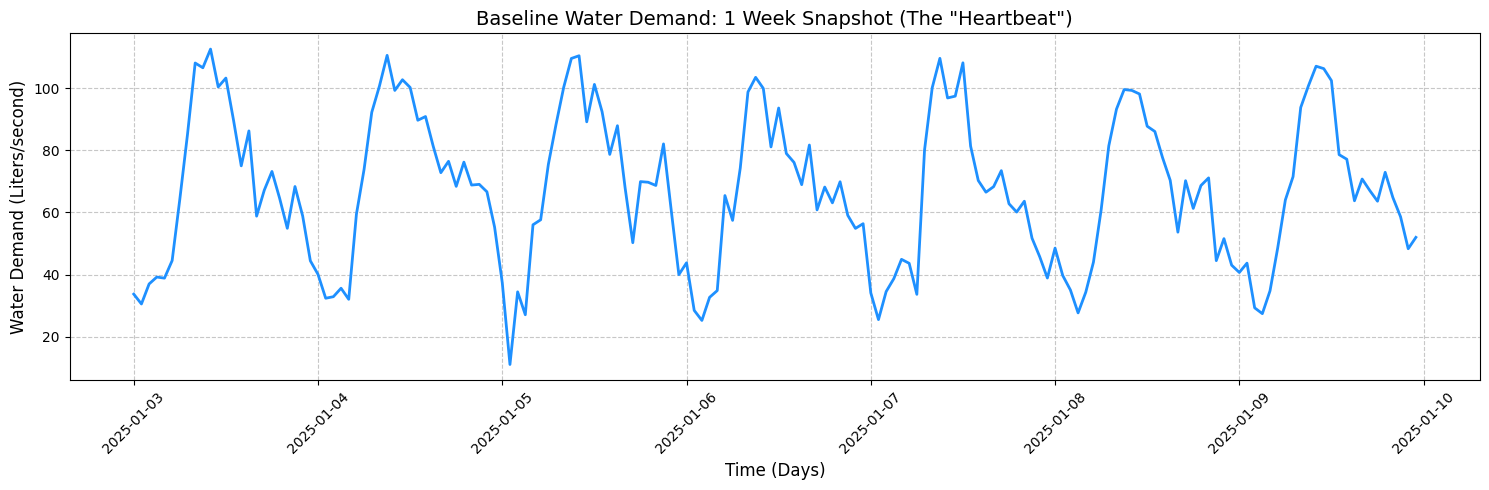

In [10]:
import matplotlib.pyplot as plt

# Plot 1 Week (168 hours) of water demand to see the daily peaks
plt.figure(figsize=(15, 5))
plt.plot(df['Timestamp'][:168], df['Current_Demand'][:168], color='dodgerblue', linewidth=2)
plt.title('Baseline Water Demand: 1 Week Snapshot (The "Heartbeat")', fontsize=14)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Water Demand (Liters/second)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()